# Missouri, November 3 2026: the pre-registration draft

*An analysis notebook for the Geo-Fluid Dynamics Engine. Exploratory
narrative — the tested library (`geofluid`) does the ingest; the model here
is deliberately simple enough to be audited line by line.*

## What this notebook is

The protocol in `docs/MEASUREMENT_DESIGN.md` §7 commits us to predicting
every statewide measure on Missouri's November 2026 ballot **county by
county, before the election**, freezing the file in git by 2026-10-15, and
scoring it in public afterwards. This notebook is the DRAFT of that file: it
assembles every Missouri statewide measure we can certify (21 contests,
2018–2026, three electorate types), picks the prediction model by backtest,
states each measure's statewide "level" as an explicit ex-ante bracket, and
writes `data/predictions/mo_2026-11-03_DRAFT_<date>.csv`. Nothing here is
registered yet; the registration commit will rename the file and stop
editing it.

## The five measures (the slate widened on 2026-09-03)

* **Amendment 3** — YES repeals the 2024 reproductive-freedom amendment
  (near-total ban). Progressive side: NO. Closest past vote: 2024 Amdt 3
  (51.6% yes).
* **Amendment 6** — YES requires an 80% legislative supermajority plus a
  statewide vote to alter voter-passed initiatives. Progressive side: YES.
  Closest: 2018 Amdt 1 Clean Missouri (62.0%), Aug-2026 Amdt 4 (80.3% NO).
* **Congressional map referendum** — YES upholds HB 1, the 2025 7–1 map.
  Progressive side: NO. Closest: 2020 Amdt 3 Clean Missouri repeal (51.0%).
* **Amendment 7** — YES creates the "Show-Me" prosperity fund toward
  replacing taxes. Progressive side: NO. Closest: 2024 Amdt 6 court fees
  (39.4%), Aug-2026 Amdt 5 income-tax phaseout (16.7%).
* **Amendment 8** — YES makes county sheriff a constitutional elected office
  with removal protection. Progressive side: NO. Closest: 2024 Amdt 7
  citizen-only / RCV ban (68.4%), Aug-2024 Amdt 4 KC police (51.1%).

"Progressive side" is the orientation convention shared with the loaders
and the catalog — a label for which answer the measure's own coalition
geography puts on the Democratic-leaning end, not an endorsement.

---

### For the field: how to read this notebook

This document has two layers. The code and the technical notes are the
audit trail — they let a skeptic check every step. The blocks headed
**For the field** are for the people who will actually use the answers:
volunteers, organizers, the nurse or the mechanic or the teacher knocking
on doors on a Saturday. You do not need any statistics to follow those.

Five words we use over and over, in plain English:

* **Share.** Out of every 100 people who voted YES or NO on a measure,
  how many picked the side we're tracking. "A share of 55" means 55 out
  of 100. We report it as a decimal in the tables (0.55 = 55 out of 100).
* **Partisanship.** How a county voted for president in 2024, as the
  Democratic slice of the two-party vote. It is the single best clue to
  how a county votes on anything — and the yardstick we have to beat.
* **Bracket.** Our statewide prediction is not one number, it's a range:
  a low, a middle, and a high. The middle is our best guess; the low and
  high are where we'd stop being surprised. If the real result lands
  outside the bracket, we were wrong, and we'll say so.
* **Analog.** A past vote that looked like this one. We learn from how
  each county behaved on the analog — the way a coach studies last
  season's tape.
* **Backtest.** Before predicting the future, we pretend past elections
  haven't happened yet, predict them, and check the score. If a method
  can't predict the past, it has no business predicting the future.

**The one idea behind everything here:** a county's vote on any issue is
mostly its partisanship, plus a personality. Some counties run ahead of
their politics on certain issues; some run behind. That personality shows
up election after election, and it is where a campaign can find voters
nobody else is looking for.

In [1]:
import re
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pdfplumber

from geofluid.ingest.referendum import parse_mo_canvass, parse_mo_enr_results
from geofluid.targeting import history_buckets

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").exists())
RAW = ROOT / "data/raw"
TODAY = date.today().isoformat()


def logit(p: "pd.Series[float]") -> "pd.Series[float]":
    return np.log(p / (1 - p))


def inv_logit(z: "pd.Series[float]") -> "pd.Series[float]":
    return 1 / (1 + np.exp(-z))

## 1. Data: 116 jurisdictions, 21 measures, three electorates

Missouri reports 114 counties + St. Louis City + **Kansas City** (which
spans four counties and carries MIT's place-code `2938000`, so it has a
real presidential baseline). Every measure below passed the loader's
built-in integrity check (parsed jurisdictions reproduce the certified
statewide total exactly). The Aug-2026 primary comes from the SoS's
Election Night Results portal — certified by the Board of State Canvassers
on 2026-08-25, served as a race page because the canvass PDF was still
unposted on 2026-09-14 — through `parse_mo_enr_results`.

In [2]:
mit = pd.read_csv(
    RAW / "countypres_2000-2024.csv", dtype={"county_fips": "string"}, low_memory=False
)
mo_rows = mit[mit["state_po"] == "MO"]
names = mo_rows[["county_name", "county_fips"]].drop_duplicates()
fips_map = {
    str(n).title(): str(f).zfill(5)
    for n, f in zip(names["county_name"], names["county_fips"], strict=True)
}
fips_map.update(
    {
        "Kansas City": "2938000",  # MIT place-code convention (spans 4 counties)
        "McDonald": "29119",  # str.title() yields "Mcdonald"
        "St. Louis": "29189",  # the canvass drops the "County" suffix
        "De Kalb": "29063",  # the ENR portal spells DeKalb with a space
    }
)
county_name = {v: k for k, v in fips_map.items()}
county_name["29189"] = "St. Louis County"


def dem_two_party(year: int) -> "pd.Series[float]":
    y = mo_rows[mo_rows["year"] == year].copy()
    y["fips"] = y["county_name"].str.title().map(fips_map)
    two = y[y["party"].isin(["DEMOCRAT", "REPUBLICAN"])]
    pv = two.pivot_table(index="fips", columns="party", values="candidatevotes", aggfunc="sum")
    return pv["DEMOCRAT"] / (pv["DEMOCRAT"] + pv["REPUBLICAN"])


dem = {year: dem_two_party(year) for year in (2016, 2020, 2024)}

CANVASSES = [
    "ActualResults-November62018-FINAL.pdf",
    "ActualResults-August72018.pdf",
    "ActualResults-August42020.pdf",
    "ActualResults-November32020.pdf",
    "ActualResults-August62024.pdf",
    "ActualResults-November52024.pdf",
]
pages = {}
for canvass in CANVASSES:
    with pdfplumber.open(RAW / canvass) as pdf:
        pages[canvass] = [page.extract_text() or "" for page in pdf.pages]

NOV18 = "ActualResults-November62018-FINAL.pdf"
NOV20 = "ActualResults-November32020.pdf"
NOV24 = "ActualResults-November52024.pdf"
# (label, canvass, contest, progressive side, electorate type)
MEASURES = [
    ("cleanmo_2018", NOV18, "Amendment 1", "yes", "midterm"),
    ("cannabis_med_2018", NOV18, "Amendment 2", "yes", "midterm"),
    ("bingo_2018", NOV18, "Amendment 4", "yes", "midterm"),
    ("minwage_2018", NOV18, "Proposition B", "yes", "midterm"),
    ("gastax_2018", NOV18, "Proposition D", "yes", "midterm"),
    ("termlimits_2020", NOV20, "Amendment 1", "yes", "presidential"),
    ("cleanmo_repeal_2020", NOV20, "Amendment 3", "no", "presidential"),
    ("sportsbet_2024", NOV24, "Amendment 2", "yes", "presidential"),
    ("abortion_2024", NOV24, "Amendment 3", "yes", "presidential"),
    ("casino_2024", NOV24, "Amendment 5", "yes", "presidential"),
    ("courtfees_2024", NOV24, "Amendment 6", "no", "presidential"),
    ("rcvban_2024", NOV24, "Amendment 7", "no", "presidential"),
    ("minwage_2024", NOV24, "Proposition A", "yes", "presidential"),
    ("rtw_2018p", "ActualResults-August72018.pdf", "Proposition A", "no", "primary"),
    ("medicaid_2020p", "ActualResults-August42020.pdf", "Amendment 2", "yes", "primary"),
    ("childcare_tax_2024p", "ActualResults-August62024.pdf", "Amendment 1", "yes", "primary"),
    ("kcpolice_2024p", "ActualResults-August62024.pdf", "Amendment 4", "no", "primary"),
]
ENR_2026 = [  # (label, amendment number, progressive side)
    ("parks_tax_2026p", 1, "yes"),
    ("jackson_assessor_2026p", 2, "no"),
    ("init_restrict_2026p", 4, "no"),
    ("income_tax_phaseout_2026p", 5, "no"),
]

shares, totals, electorate = {}, {}, {}
for label, canvass, contest, side, etype in MEASURES:
    panel = parse_mo_canvass(pages[canvass], contest, fips_map).set_index("fips")
    shares[label] = 1 - panel["no_share"] if side == "yes" else panel["no_share"]
    totals[label] = panel["total_votes"]
    electorate[label] = etype
for label, number, side in ENR_2026:
    text = (RAW / f"enr_mo_20260804_amendment_{number}.txt").read_text(encoding="utf-8")
    panel = parse_mo_enr_results(text, fips_map).set_index("fips")
    shares[label] = 1 - panel["no_share"] if side == "yes" else panel["no_share"]
    totals[label] = panel["total_votes"]
    electorate[label] = "primary"
share = pd.DataFrame(shares)
total = pd.DataFrame(totals)
statewide = (share * total).sum() / total.sum()
print(f"{share.shape[0]} jurisdictions x {share.shape[1]} measures")
print(
    pd.DataFrame(
        {"progressive_share_statewide": statewide.round(4), "electorate": pd.Series(electorate)}
    ).to_string()
)

116 jurisdictions x 21 measures
                           progressive_share_statewide    electorate
cleanmo_2018                                    0.6202       midterm
cannabis_med_2018                               0.6559       midterm
bingo_2018                                      0.5239       midterm
minwage_2018                                    0.6234       midterm
gastax_2018                                     0.4640       midterm
termlimits_2020                                 0.4716  presidential
cleanmo_repeal_2020                             0.4899  presidential
sportsbet_2024                                  0.5005  presidential
abortion_2024                                   0.5160  presidential
casino_2024                                     0.4754  presidential
courtfees_2024                                  0.6061  presidential
rcvban_2024                                     0.3156  presidential
minwage_2024                                    0.5757  presidential
rt

**For the field — what you just saw.**

*What we did:* we collected the official, certified results for every
statewide ballot question Missouri has voted on since 2018 — 21 of them —
for all 116 places the state reports (114 counties, St. Louis City, and
Kansas City). Every number was checked against the state's own totals to
the last vote before we used it.

*Why:* you can't learn a county's habits from one vote. Twenty-one votes
on abortion, wages, marijuana, gambling, taxes, redistricting and more,
across eight years, is enough to see which counties consistently surprise.

*How to read the table:* one row per past ballot question. The share is
the statewide result for the side we're tracking (0.6202 means 62 out of
every 100 voters). The "electorate" column says which kind of election it
was — a presidential November, a midterm November, or an August primary —
because different crowds show up for each, and that matters (see §3).

*What it means for you:* the raw material is real votes, not polls. Nobody
was asked what they'd do; this is what they did.

### A midterm partisan baseline: the 2018 U.S. Senate race

MIT's file is presidential only. Missouri's 2018 canvass gives us the last
midterm electorate's partisan vote directly (Hawley–McCaskill). This is an
ad hoc, notebook-grade parse of a candidate race — so it is validated the
only way that counts, against the certified statewide totals.

In [3]:
senate_rows = []
row_re = re.compile(r"^([A-Za-z][A-Za-z .'\-]*?)((?:\s+[\d,]+){6})$")
for page in pages[NOV18]:
    if "United States Senator" not in page:
        continue
    for line in page.splitlines():
        m = row_re.match(line.strip())
        if m and m.group(1) != "Total":
            nums = [int(x.replace(",", "")) for x in m.group(2).split()]
            senate_rows.append((fips_map[m.group(1)], nums[0], nums[1]))
senate18 = pd.DataFrame(senate_rows, columns=["fips", "hawley", "mccaskill"]).set_index("fips")
certified_2018 = (1254927, 1112935)
parsed_2018 = (int(senate18["hawley"].sum()), int(senate18["mccaskill"].sum()))
if parsed_2018 != certified_2018:
    raise ValueError(f"2018 Senate parse {parsed_2018} != certified {certified_2018}")
dem18_senate = senate18["mccaskill"] / (senate18["hawley"] + senate18["mccaskill"])
pres_1620 = ((dem[2016] + dem[2020]) / 2).reindex(dem18_senate.index)
print(f"2018 Senate: {len(senate18)} jurisdictions; certified statewide totals reproduced exactly")
r_senate = np.corrcoef(dem18_senate, pres_1620)[0, 1]
print(f"corr(dem 2018 Senate, dem pres 2016/2020 avg) = {r_senate:.3f}")

2018 Senate: 116 jurisdictions; certified statewide totals reproduced exactly
corr(dem 2018 Senate, dem pres 2016/2020 avg) = 0.973


**For the field — what you just saw.**

*What we did:* November 2026 is a midterm — no presidential race on the
ballot — so we pulled the last midterm's big statewide race (the 2018
Senate contest) county by county, and confirmed our copy adds up to the
state's certified totals exactly.

*Why:* the crowd that votes in a midterm is not the same crowd as in a
presidential year. We wanted to know whether counties line up the same
way when the smaller crowd shows up.

*How to read the number:* "corr" is a correlation — a score from −1 to
+1 for how tightly two lists move together. 0 means no relationship; 1
means they march in lockstep. Ours is about 0.97: the county order in a
midterm is almost identical to a presidential year.

*What it means for you:* a county that is friendly ground in a
presidential year is friendly ground in a midterm too. What changes is
how many people show up, not who the county is.

## 2. Choosing the model by backtest

Three candidate models for a county's share on a *new* measure, all on the
logit scale and all with the statewide level treated as given (the level
is a separate, explicitly-bracketed judgement — see §4 — so the backtest
isolates the *county pattern* skill):

1. **Partisanship only** — `logit(share) = a + b·logit(dem two-party)` of
   the measure's own era. The baseline we claim to beat.
2. **Pooled position** — the mean standardized logit share across all
   *other* general-election measures (the design doc's ideal point, built
   the simple way).
3. **Partisanship + analog residual** — model 1 plus `k` times the
   partisanship residual of the closest past measure (the tested
   `issue_resistance` idea: a county that defied its partisan peers on the
   analog is expected to defy them again).

Every fit is leave-one-out on the measure being predicted; the analog's
residual is computed from the analog's own era baseline.

In [4]:
L = logit(share.clip(0.01, 0.99))
general = [m[0] for m in MEASURES if m[4] != "primary"]
ERA_BASELINE = {
    "2018": (dem[2016] + dem[2020]) / 2,
    "2020": dem[2020],
    "2024": dem[2024],
    "2026": dem[2024],
}


def era_of(label: str) -> str:
    match = re.search(r"(20\d\d)", label)
    if match is None:
        raise ValueError(label)
    return match.group(1)


def partisan_fit(label: str) -> tuple[float, float, "pd.Series[float]"]:
    """OLS of a measure's logit share on its era's logit partisanship; returns
    intercept, slope, residual (fips-indexed)."""
    y = L[label]
    x = logit(ERA_BASELINE[era_of(label)].reindex(y.index))
    slope, intercept = np.polyfit(x, y, 1)
    return float(intercept), float(slope), y - (intercept + slope * x)


def rmse_pp(pred_logit: "pd.Series[float]", label: str) -> float:
    return float(np.sqrt(((inv_logit(pred_logit) - share[label]) ** 2).mean()) * 100)


weights = total["abortion_2024"] / total["abortion_2024"].sum()


def standardized(label: str) -> "pd.Series[float]":
    mean = (L[label] * weights).sum()
    sd = np.sqrt((((L[label] - mean) ** 2) * weights).sum())
    return (L[label] - mean) / sd


Z = pd.DataFrame({m: standardized(m) for m in general})

# Analog pairs for model 3: the closest earlier measure by content
# (same issue where one exists; nearest governance/tax sibling otherwise).
ANALOG_BACKTEST = {
    "minwage_2024": "minwage_2018",
    "cleanmo_repeal_2020": "cleanmo_2018",
    "abortion_2024": "minwage_2024",  # cross-issue: the Ohio-style trait test
    "casino_2024": "sportsbet_2024",
    "courtfees_2024": "termlimits_2020",
    "rcvban_2024": "cleanmo_repeal_2020",
    "sportsbet_2024": "bingo_2018",
    "gastax_2018": "bingo_2018",
}
K_GRID = (0.5, 0.75, 1.0)

rows = []
for label in general:
    intercept, slope, _resid = partisan_fit(label)
    x = logit(ERA_BASELINE[era_of(label)].reindex(L.index))
    pred1 = intercept + slope * x
    pos = Z[[m for m in general if m != label]].mean(axis=1)
    s2, i2 = np.polyfit(pos, L[label], 1)
    pred2 = i2 + s2 * pos
    row: dict[str, object] = {
        "measure": label,
        "partisan_only": rmse_pp(pred1, label),
        "pooled_position": rmse_pp(pred2, label),
    }
    if label in ANALOG_BACKTEST:
        _, _, analog_resid = partisan_fit(ANALOG_BACKTEST[label])
        for k in K_GRID:
            pred3 = pred1 + k * analog_resid.reindex(L.index)
            row[f"partisan+analog k={k}"] = rmse_pp(pred3, label)
        row["analog"] = ANALOG_BACKTEST[label]
    rows.append(row)
backtest = pd.DataFrame(rows).set_index("measure")
print("county RMSE in percentage points (statewide level given):")
print(backtest.round(2).to_string())
print("\nmeans:")
print(backtest.drop(columns="analog").mean().round(2).to_string())

county RMSE in percentage points (statewide level given):
                     partisan_only  pooled_position  partisan+analog k=0.5  partisan+analog k=0.75  partisan+analog k=1.0               analog
measure                                                                                                                                       
cleanmo_2018                  4.37             4.21                    NaN                     NaN                    NaN                  NaN
cannabis_med_2018             3.95             4.26                    NaN                     NaN                    NaN                  NaN
bingo_2018                    3.32             2.81                    NaN                     NaN                    NaN                  NaN
minwage_2018                  3.66             4.13                    NaN                     NaN                    NaN                  NaN
gastax_2018                   5.21             5.05                   4.54          

**For the field — what you just saw.**

*What we did:* we took each of the 13 past November ballot questions,
hid its county results, predicted them three different ways using only
the OTHER votes, and then checked the score. That's the backtest.

*Why:* anyone can draw a map of the future. The question is whether the
method has ever been right. This table is the proof — or the lack of it.

*How to read the table:* every number is an average miss in **points out
of 100**. If a method says a county will vote 52 and the county votes 55,
that's a miss of 3. "3.69" means the plain-partisanship method missed the
typical county by about 3.7 points. Smaller is better. The columns are
the three methods; the bottom "means" row is the overall score.

*What the numbers mean:*
* **Partisanship alone is very good.** Knowing how a county voted for
  president gets you within about 3.7 points on almost any issue. That
  is the bar. Anything we sell has to beat it, and we say so in writing.
* **The fancy "pooled position" idea did NOT beat it.** We tried; it
  scored 3.80. We're telling you because a tool that only shows you its
  wins is a sales pitch, not a tool.
* **Learning from a look-alike past vote DID beat it** — when the
  look-alike was real (minimum wage predicting minimum wage; sports betting
  predicting casinos). Then the miss drops to the mid-2s. When we forced a
  weak comparison, it got worse. Lesson: the method only helps when the
  history genuinely rhymes, and we only use it where it does.

**Reading the backtest.** Partisanship alone is a strong baseline — the
pooled position does *not* beat it on average (it helps on low-salience
gambling/tax measures where partisanship is loose, and hurts on the
hot-button ones where partisanship already explains 90%+ of the
variance). The analog residual is where the skill is — but only when the
analog is a true sibling: minimum wage 2018 → 2024, sports betting →
casino, and minimum wage → abortion (the cross-issue trait) all cut county
error by a quarter to a half, while flavor-guess analogs (term limits →
court fees, Clean Missouri repeal → RCV ban) make it worse. Shrinking the
residual by half is the compromise that wins on average, so we register
**model 3 with k = 0.5** and keep same-issue analogs where they exist.

In [5]:
k_cols = [c for c in backtest.columns if c.startswith("partisan+analog")]
k_table = backtest[["partisan_only", *k_cols]].dropna()
print(k_table.round(2).to_string())
print("\nmean over measures with an analog:")
print(k_table.mean().round(2).to_string())
K = 0.5  # registered shrinkage — best mean in the table; revisit ONLY before registration

                     partisan_only  partisan+analog k=0.5  partisan+analog k=0.75  partisan+analog k=1.0
measure                                                                                                 
gastax_2018                   5.21                   4.54                    4.40                   4.40
cleanmo_repeal_2020           3.01                   3.01                    3.55                   4.30
sportsbet_2024                4.40                   4.14                    4.24                   4.49
abortion_2024                 2.69                   2.42                    2.68                   3.16
casino_2024                   4.07                   2.42                    2.05                   2.22
courtfees_2024                4.30                   4.95                    5.36                   5.82
rcvban_2024                   2.79                   2.95                    3.19                   3.51
minwage_2024                  3.58                   2.

**For the field — what you just saw.**

*What we did:* when a county surprised us on the look-alike vote, how
much of that surprise should we expect again? All of it? Half? We tried
three settings (0.5, 0.75, 1.0 — meaning half, three-quarters, all) and
kept the one with the best score on past elections: **half**.

*How to read the table:* same as before — average miss in points out of
100, smaller is better — with one column per setting. The bottom row is
the average across the measures that had a look-alike.

*What it means for you:* a county's personality is real but it doesn't
repeat in full. If a county ran 6 points ahead of its politics last
time, bank on about 3 this time, not 6. That's the difference between
a target list you can trust and one that burns a weekend.

## 3. The electorate question

Two things could break a midterm prediction built on presidential
baselines: the *level* (who turns out) and the *pattern* (whether counties
keep their relative order). The level is handled by the bracket in §4. For
the pattern, three checks:

In [6]:
midterm = [m[0] for m in MEASURES if m[4] == "midterm"]
presidential = [m[0] for m in MEASURES if m[4] == "presidential"]
pos_mid = Z[midterm].mean(axis=1)
pos_pres = Z[presidential].mean(axis=1)
r_a = np.corrcoef(pos_mid, pos_pres)[0, 1]
r_b = np.corrcoef(dem18_senate, dem[2024].reindex(dem18_senate.index))[0, 1]
print(f"(a) county position from 2018 midterm vs presidential-year measures: r = {r_a:.3f}")
print(f"(b) 2018 Senate two-party Dem share vs 2024 presidential: r = {r_b:.3f}")
print("(c) the Aug-2026 primary (a real 2026 electorate) against the 2024 presidential baseline:")
x24 = logit(dem[2024].reindex(L.index))
for label, _n, _s in ENR_2026:
    r_c = np.corrcoef(x24, L[label])[0, 1]
    print(f"    {label:28s} r = {r_c:+.3f}   statewide progressive share {statewide[label]:.3f}")

(a) county position from 2018 midterm vs presidential-year measures: r = 0.897
(b) 2018 Senate two-party Dem share vs 2024 presidential: r = 0.959
(c) the Aug-2026 primary (a real 2026 electorate) against the 2024 presidential baseline:
    parks_tax_2026p              r = +0.734   statewide progressive share 0.823
    jackson_assessor_2026p       r = -0.283   statewide progressive share 0.231
    init_restrict_2026p          r = +0.476   statewide progressive share 0.803
    income_tax_phaseout_2026p    r = -0.089   statewide progressive share 0.833


**For the field — what you just saw.**

*What we did:* three checks on the biggest worry — that a midterm crowd
behaves differently from a presidential crowd. (a) Do counties keep the
same personality across the two kinds of election? (b) Does the 2018
midterm Senate vote line up with the 2024 presidential vote? (c) The
newest test of all: this August's Missouri primary, a real 2026
electorate — did counties still line up by partisanship?

*How to read the numbers:* these are correlations again (−1 to +1; near
1 means "same order"). (a) is about 0.90 and (b) about 0.96: strong. In
(c), Amendment 4 — the legislature's attempt to make citizen initiatives
harder — was crushed 80–20, yet counties still lined up by partisanship
(about +0.5). The two low-profile items (the Jackson County assessor, the
income-tax phaseout) show almost no partisan pattern at all.

*What it means for you:* on issues people care about, the map of who's
with you holds up even when the crowd changes. On sleepy, technical
measures, partisanship tells you much less — expect the map to be flat,
and don't over-plan around county differences for those.

The county *pattern* is stable across electorate types for measures with
partisan structure (the direct-democracy measure Amendment 4 in Aug 2026
still ordered counties by partisanship even in a landslide); the
low-salience referrals (Jackson County assessor, income-tax phaseout) have
almost no partisan structure at all — which is exactly why their 2026
siblings (Amendments 7 and 8) get the humblest intervals below.

**Turnout weights.** For the statewide aggregation of county predictions
we assume each jurisdiction's share of the 2026 vote equals its share of
the 2018 midterm vote (Clean Missouri's total votes). This is an explicit
assumption; the file also carries the 2024-presidential-weighted variant.

In [7]:
turnout_2018 = total["cleanmo_2018"] / total["cleanmo_2018"].sum()
turnout_2024 = total["abortion_2024"] / total["abortion_2024"].sum()

## 4. The five measures: analogs and ex-ante level brackets

The **level** is the statewide progressive share we expect. It is a
judgement, stated before the fact, with the reasoning written down so it
can be scored as a judgement. The county pattern then comes from the
registered model (slope from the analog's era fit, analog residual shrunk
by `K`), shifted so the turnout-weighted statewide share equals the level.

* **Amdt 3 (abortion repeal; progressive = NO): 51.5 / 55.0 / 59.0.**
  The 2024 rights side won 51.6% on a presidential electorate. A near-total
  ban is a harsher cutpoint than a viability right — in KS-2022, KY-2022
  and OH-2023 the ban side under-performed the state's partisan lean by
  8–15 points. Midterm 2022 electorates favored the rights side, and
  Aug-2026's 80–20 rejection of Amendment 4 shows an anti-legislature mood.
  Low end: the 2024 coalition merely holds.
* **Amdt 6 (initiative protection; progressive = YES): 55 / 62 / 70.**
  Clean Missouri 2018 (anti-legislature reform) got 62.0% on a midterm —
  the same electorate type; Aug-2026 Amendment 4 (the legislature's
  initiative restriction) lost 80–20. Risk: the 80% threshold reads as
  extreme and the opposition will call it a lock-in.
* **Map referendum (progressive = NO = reject HB 1): 46 / 53 / 60.** The
  2020 Clean Missouri repeal — the legislature's last redistricting power
  play — passed 51.0% on a presidential electorate. A referendum on a
  mid-decade gerrymander is more legible and the 2026 mood is
  anti-legislature, but partisan salience will be maximal and Missouri
  leans R+18. Genuinely close; widest bracket.
* **Amdt 7 (prosperity fund; progressive = NO): 50 / 58 / 68.** Missouri
  voters default NO on referrals they don't understand (2024 court fees 39%
  yes, 2020 term limits 47%, Aug-2024 childcare 45%), and the
  tax-elimination agenda's own Amendment 5 just lost 83–17. Softer, vaguer
  text than Amdt 5 keeps it off the landslide floor.
* **Amdt 8 (sheriffs; progressive = NO): 28 / 36 / 45.** Pro-law-enforcement,
  populist, low-controversy: closest to 2024 Amendment 7 (68.4% yes) in
  flavor; passes comfortably unless the removal-protection clause draws
  organized opposition.

In [8]:
SLATE = [
    # (measure_id, ballot label, progressive side, analogs, (low, central, high) level)
    (
        "mo_20261103_amendment_3",
        "Amendment 3 — repeal 2024 reproductive-freedom amendment",
        "no",
        ["abortion_2024"],
        (0.515, 0.550, 0.590),
    ),
    (
        "mo_20261103_amendment_6",
        "Amendment 6 — Respect Missouri Voters (initiative protection)",
        "yes",
        ["cleanmo_2018", "init_restrict_2026p"],
        (0.55, 0.62, 0.70),
    ),
    (
        "mo_20261103_map_referendum",
        "Congressional map referendum on HB 1",
        "no",
        ["cleanmo_repeal_2020"],
        (0.46, 0.53, 0.60),
    ),
    (
        "mo_20261103_amendment_7",
        "Amendment 7 — Show-Me prosperity fund",
        "no",
        ["courtfees_2024", "income_tax_phaseout_2026p"],
        (0.50, 0.58, 0.68),
    ),
    (
        "mo_20261103_amendment_8",
        "Amendment 8 — constitutional elected sheriffs",
        "no",
        ["rcvban_2024", "kcpolice_2024p"],
        (0.28, 0.36, 0.45),
    ),
]


def county_pattern(analogs: list[str]) -> "pd.Series[float]":
    """The registered model's county pattern for a new measure: the mean of
    the analogs' partisan slopes applied to 2024 partisanship, plus K times
    the mean analog residual. Un-levelled (the level shift is applied next)."""
    slopes, resids = [], []
    for analog in analogs:
        _i, slope, resid = partisan_fit(analog)
        slopes.append(slope)
        resids.append(resid.reindex(L.index))
    return float(np.mean(slopes)) * x24 + K * pd.concat(resids, axis=1).mean(axis=1)


def level_shift(
    pattern: "pd.Series[float]", level: float, w: "pd.Series[float]"
) -> "pd.Series[float]":
    """Find the additive logit shift that makes the turnout-weighted statewide
    progressive share equal the stated level (bisection; monotone)."""
    lo, hi = -10.0, 10.0
    for _ in range(80):
        mid = (lo + hi) / 2
        if float((inv_logit(pattern + mid) * w).sum()) < level:
            lo = mid
        else:
            hi = mid
    return inv_logit(pattern + (lo + hi) / 2)


# County-level uncertainty from the backtest: the analog model's RMSE in
# logit units, averaged over the measures where an analog existed. The 90%
# interval is honest about pattern error ON TOP of the level bracket.
analog_errors = []
for lbl, analog in ANALOG_BACKTEST.items():
    intercept, slope, _r = partisan_fit(lbl)
    pred = (
        intercept
        + slope * logit(ERA_BASELINE[era_of(lbl)].reindex(L.index))
        + K * partisan_fit(analog)[2].reindex(L.index)
    )
    analog_errors.append(float(np.sqrt(((pred - L[lbl]) ** 2).mean())))
pattern_rmse_logit = float(np.mean(analog_errors))
print(f"pattern RMSE (logit units) from the analog-model backtest: {pattern_rmse_logit:.3f}")

pattern RMSE (logit units) from the analog-model backtest: 0.147


In [9]:
z90 = 1.645 * pattern_rmse_logit
records = []
for measure_id, ballot, side, analogs, (low, central, high) in SLATE:
    pattern = county_pattern(analogs)
    pred_low = level_shift(pattern, low, turnout_2018)
    pred_mid = level_shift(pattern, central, turnout_2018)
    pred_high = level_shift(pattern, high, turnout_2018)
    pred_mid_24w = level_shift(pattern, central, turnout_2024)
    mid_logit = logit(pred_mid)
    band_lo = inv_logit(mid_logit - z90)
    band_hi = inv_logit(mid_logit + z90)
    for fips in L.index:
        records.append(
            {
                "measure_id": measure_id,
                "ballot": ballot,
                "progressive_side": side,
                "fips": fips,
                "county": county_name.get(fips, fips),
                "dem_two_party_2024": round(float(dem[2024].get(fips, np.nan)), 4),
                "pred_progressive_share": round(float(pred_mid[fips]), 4),
                "pred_low_90": round(float(min(pred_low[fips], band_lo[fips])), 4),
                "pred_high_90": round(float(max(pred_high[fips], band_hi[fips])), 4),
                "level_low": low,
                "level_central": central,
                "level_high": high,
                "analogs": "+".join(analogs),
                "turnout_weights": "2018 midterm",
                "pred_central_2024_turnout_weights": round(float(pred_mid_24w[fips]), 4),
            }
        )
predictions = pd.DataFrame(records)

summary_rows = []
for measure_id, *_rest in SLATE:
    g = predictions[predictions["measure_id"] == measure_id].set_index("fips")
    summary_rows.append(
        {
            "measure_id": measure_id,
            "statewide_progressive_central": float(
                (g["pred_progressive_share"] * turnout_2018).sum()
            ),
            # the SAME county predictions aggregated with 2024's county turnout
            # shares: how much the turnout-composition assumption moves the state
            "statewide_if_2024_turnout_pattern": float(
                (g["pred_progressive_share"] * turnout_2024).sum()
            ),
            "counties_progressive_majority": int((g["pred_progressive_share"] > 0.5).sum()),
            "min_county": float(g["pred_progressive_share"].min()),
            "max_county": float(g["pred_progressive_share"].max()),
        }
    )
print(pd.DataFrame(summary_rows).set_index("measure_id").round(3).to_string())

                            statewide_progressive_central  statewide_if_2024_turnout_pattern  counties_progressive_majority  min_county  max_county
measure_id                                                                                                                                         
mo_20261103_amendment_3                              0.55                              0.541                             11       0.239       0.851
mo_20261103_amendment_6                              0.62                              0.616                            105       0.458       0.781
mo_20261103_map_referendum                           0.53                              0.524                             12       0.311       0.720
mo_20261103_amendment_7                              0.58                              0.579                            116       0.502       0.646
mo_20261103_amendment_8                              0.36                              0.357                    

**For the field — what you just saw.**

*What we did:* for each of the five November measures, we built the
county-by-county prediction: start from each county's partisanship, add
half of its personality from the look-alike vote, then slide the whole
map up or down until the statewide total matches our bracket's middle.

*How to read the table:* one row per measure. "statewide_progressive_
central" is our middle statewide call for the side we're tracking (0.55
= 55 out of 100). "counties_progressive_majority" is how many of the 116
places we expect that side to WIN outright. "min" and "max" are the
coolest and warmest county. The "if_2024_turnout" column is a what-if:
the same county predictions, but assuming a presidential-year crowd
instead of a midterm one — it barely moves, which is reassuring.

*What the numbers mean, measure by measure:*
* **Amendment 3 (abortion repeal).** We expect the NO side (keep the 2024
  rights) around 55 out of 100 statewide — but winning only about 11 of
  116 places. That's Missouri: a few big urban and college counties carry
  a statewide majority while most of the map votes the other way. The
  fight is turnout in the 11 and margins in the next 20.
* **Amendment 6 (protect voter initiatives).** Around 62 for YES, winning
  most counties. Broad, shallow support — an issue where rural and urban
  voters largely agree, which is rare and worth knowing.
* **Map referendum.** A coin flip, about 53 for rejecting the map, with
  roughly a dozen counties on that side. This one will be decided by
  turnout more than persuasion.
* **Amendment 7 (prosperity fund).** NO around 58, and almost every county
  leans NO — voters tend to reject tax schemes they can't picture.
* **Amendment 8 (sheriffs).** Passes comfortably (we track the NO side at
  36); not a single county is expected to reject it.

## 5. What the map would look like — and the partisanship-only baseline we claim to beat

The registered scorecard compares our county predictions with a
partisanship-only prediction at the SAME level (so the comparison is about
pattern skill, not about who guessed the statewide number). Both are
written to the file.

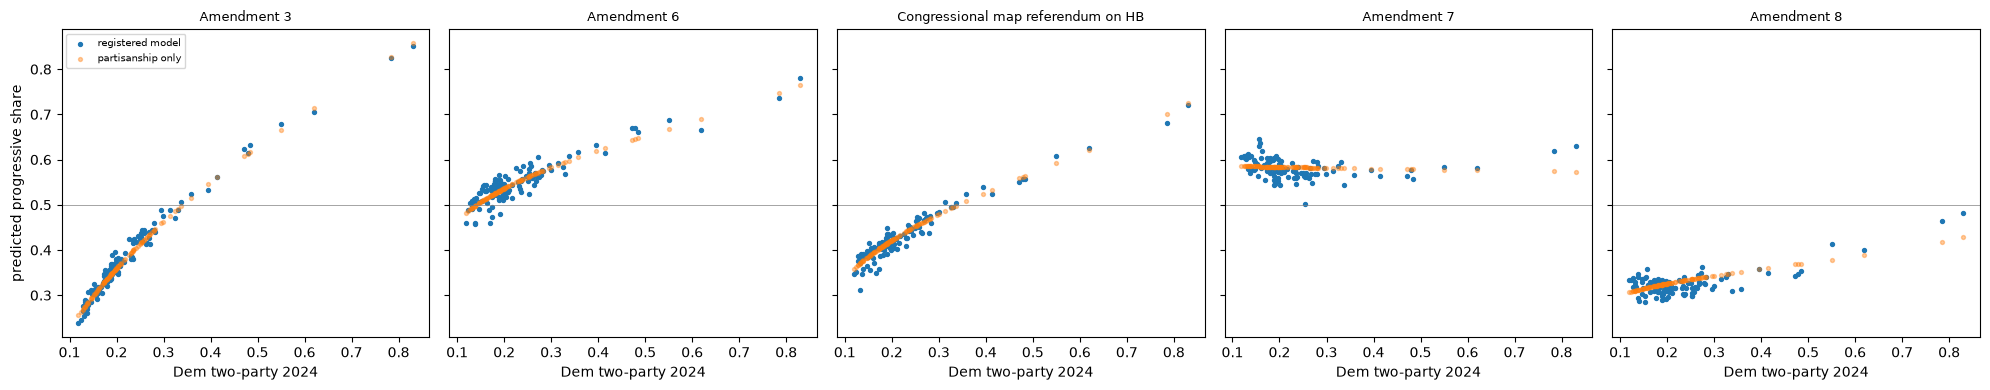

In [10]:
baseline_records = []
for measure_id, _b, _s, analogs, (_lo, central, _hi) in SLATE:
    slope = float(np.mean([partisan_fit(a)[1] for a in analogs]))
    base = level_shift(slope * x24, central, turnout_2018)
    baseline_records.extend(
        {"measure_id": measure_id, "fips": f, "baseline_partisan_only": round(float(base[f]), 4)}
        for f in L.index
    )
predictions = predictions.merge(pd.DataFrame(baseline_records), on=["measure_id", "fips"])

fig, axes = plt.subplots(1, len(SLATE), figsize=(4 * len(SLATE), 4), sharey=True)
for ax, (measure_id, ballot, *_rest) in zip(axes, SLATE, strict=True):
    g = predictions[predictions["measure_id"] == measure_id]
    ax.scatter(g["dem_two_party_2024"], g["pred_progressive_share"], s=8, label="registered model")
    ax.scatter(
        g["dem_two_party_2024"],
        g["baseline_partisan_only"],
        s=8,
        alpha=0.4,
        label="partisanship only",
    )
    ax.axhline(0.5, color="grey", lw=0.5)
    ax.set_title(ballot.split(" — ")[0][:34], fontsize=9)
    ax.set_xlabel("Dem two-party 2024")
axes[0].set_ylabel("predicted progressive share")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

**For the field — how to read the five charts.**

Each chart is one measure. Every dot is a county. Left-to-right is how
Democratic the county voted for president in 2024 (further right = more
Democratic). Bottom-to-top is our predicted share for the side we're
tracking. The grey line is 50 — above it, that side wins the county.

Two sets of dots: the faint ones are "partisanship only" (what you'd
predict knowing nothing but the presidential vote); the solid ones are
our prediction. **Where a solid dot sits above its faint twin, we think
that county is friendlier to the cause than its politics suggest.** Those
are the counties worth a second look. Where the solid dot sits below,
the county is tougher than it looks — don't be fooled by the party label.

Notice how steep the abortion chart is and how flat the sheriffs chart
is: the steeper the slope, the more the issue is a party-line vote and
the more the map tells you where to go. A flat chart means the issue
cuts across party, and county targeting matters less than message.

## 6. Write the DRAFT file

Not registered. The registration commit (by 2026-10-15) will copy this to
a file without `DRAFT` in the name and never edit it again; a later
revision, if any, is a NEW dated file and this one still gets scored.

In [11]:
out_dir = ROOT / "data/predictions"
out_dir.mkdir(exist_ok=True)
out = out_dir / f"mo_2026-11-03_DRAFT_{TODAY}.csv"
predictions.to_csv(out, index=False)
n_measures = predictions["measure_id"].nunique()
n_fips = predictions["fips"].nunique()
print(f"wrote {out.relative_to(ROOT)}: {len(predictions)} rows ({n_measures} x {n_fips})")
show_cols = [
    "county",
    "dem_two_party_2024",
    "pred_progressive_share",
    "pred_low_90",
    "pred_high_90",
    "baseline_partisan_only",
]
amdt3 = predictions[predictions["measure_id"] == "mo_20261103_amendment_3"]
print("\nAmendment 3 - most pro-rights predicted:")
print(amdt3.nlargest(5, "pred_progressive_share")[show_cols].to_string(index=False))
print("\nAmendment 3 - least:")
print(amdt3.nsmallest(5, "pred_progressive_share")[show_cols].to_string(index=False))
print("\nAmendment 3 - where the model departs most from partisanship alone:")
amdt3 = amdt3.assign(departure=amdt3["pred_progressive_share"] - amdt3["baseline_partisan_only"])
departures = amdt3.reindex(amdt3["departure"].abs().sort_values(ascending=False).index)
print(departures.head(8)[[*show_cols, "departure"]].to_string(index=False))

wrote data\predictions\mo_2026-11-03_DRAFT_2026-09-15.csv: 580 rows (5 x 116)

Amendment 3 - most pro-rights predicted:
          county  dem_two_party_2024  pred_progressive_share  pred_low_90  pred_high_90  baseline_partisan_only
  St. Louis City              0.8300                  0.8509       0.8175        0.8790                  0.8572
     Kansas City              0.7848                  0.8243       0.7865        0.8566                  0.8263
St. Louis County              0.6192                  0.7063       0.6538        0.7538                  0.7141
           Boone              0.5498                  0.6795       0.6248        0.7297                  0.6654
          Platte              0.4841                  0.6333       0.5756        0.6874                  0.6171

Amendment 3 - least:
   county  dem_two_party_2024  pred_progressive_share  pred_low_90  pred_high_90  baseline_partisan_only
   Wright              0.1187                  0.2386       0.1975        0.2852 

**For the field — how to read the Amendment 3 tables.**

*The columns:* `dem_two_party_2024` is the county's partisanship (0.33 =
33 of every 100 two-party presidential votes went Democratic).
`pred_progressive_share` is our call for the NO side (keep the 2024
rights). `pred_low_90` and `pred_high_90` are the range we'd bet on —
nine times in ten, the real result should land between them.
`baseline_partisan_only` is what you'd guess from politics alone.

*The first table* is the friendliest ground: St. Louis City, Kansas
City, St. Louis County, Boone (Columbia), Platte. These are the counties
that carry the statewide majority; the job there is turnout, not
persuasion — every supporter who stays home costs a vote you can't get
back anywhere else.

*The second table* is the toughest ground: NO share in the low 20s.
Nobody should spend a Saturday there unless it's home.

*The third table is the one to print out.* These are the counties where
our prediction runs furthest ABOVE what partisanship alone would say —
Clark, Atchison, Camden, Saline, Ray, Carroll, Randolph, Holt. Every one
of them voted heavily Republican for president, yet each ran a few
points ahead of its politics on abortion rights in 2024 and we expect a
share of it to carry over. The "departure" column is the size of that
edge, in share (0.04 = 4 points out of 100). Saline sits right at 50:
a genuine toss-up county in deep-red territory. These are the places
where a persuasion conversation is worth having — voters there have
already shown they'll cross the line on this issue.

*A caution:* the edge is a few points, not a landslide. It's the
difference between a wasted trip and a productive one, not between
losing and winning a county.

## 6b. For the decision-maker: where a dollar buys the most votes

The volunteer asks "where do I knock?" The person running the
organization asks a harder question: **"why should my people and my
money go to St. Charles County instead of St. Louis County or Jefferson
County?"** Shares don't answer that — votes do. A 3-point edge in a
county of 8,000 voters is 240 votes; the same edge in a county of
400,000 is 12,000. So this section converts the Amendment 3 map into
votes, using a 2018-sized midterm turnout as the expected 2026 turnout.

Three numbers per county:

* **votes_per_point** — how many votes one point of movement is worth
  there (expected votes ÷ 100). This is the price list: it tells you what
  a point of persuasion or a point of turnout BUYS in each county.
* **headroom_votes** — the county's personality edge (our prediction
  minus partisanship alone) expressed in votes: the votes we believe are
  already leaning our way beyond what the party label suggests.
* **margin_votes** — the predicted winning or losing margin in votes.

And a bucket - but NOT read off our own forecast. `targeting.history_buckets`
(tested) derives it from the county's RECORD: its habitual gap to the
statewide result on the analog vote, added to the stated statewide level.
**TURNOUT** ground (the record says it lands clearly ahead: every supporter
who stays home is a lost vote), **PERSUADE** ground (the record says it
lands near 50: conversations change the outcome), **SKIP** (the record says
it lands clearly behind). One certified vote plus one stated assumption.

In [12]:
expected_votes = (turnout_2018 * float(total["cleanmo_2018"].sum())).round()
alloc = amdt3.set_index("fips").copy()
alloc["expected_votes_2026"] = expected_votes.reindex(alloc.index)
alloc["votes_per_point"] = (alloc["expected_votes_2026"] / 100).round()
alloc["headroom_votes"] = (alloc["departure"] * alloc["expected_votes_2026"]).round()
alloc["margin_votes"] = (
    (alloc["pred_progressive_share"] - 0.5) * alloc["expected_votes_2026"]
).round()
LEVEL_AMDT3 = 0.55  # the bracket's middle, from SLATE
ELECTORATE_GENERAL = {m: electorate[m] for m in general}
# The bucket for THIS measure rests on the same-issue record (the 2024
# abortion vote) at the stated level; the county's broader character comes
# from its record on all 13 general-election measures.
record_abortion = history_buckets(
    share[["abortion_2024"]], statewide[["abortion_2024"]], LEVEL_AMDT3
)
record_general = history_buckets(
    share[general], statewide[general], LEVEL_AMDT3, electorate=ELECTORATE_GENERAL
)
alloc["bucket"] = (
    record_abortion["bucket"].reindex(alloc.index).str.upper().replace({"HARD": "SKIP"})
)
alloc["record_bucket_13"] = record_general["bucket"].reindex(alloc.index).str.upper()
alloc["midterm_penalty"] = record_general["midterm_penalty"].reindex(alloc.index).round(3)
alloc_cols = [
    "county",
    "bucket",
    "expected_votes_2026",
    "pred_progressive_share",
    "baseline_partisan_only",
    "votes_per_point",
    "headroom_votes",
    "margin_votes",
    "record_bucket_13",
    "midterm_penalty",
]
print("The three counties in the question (Amendment 3, pro-rights NO side):")
print(alloc.loc[["29183", "29189", "29099"], alloc_cols].to_string(index=False))
print("\nPERSUADE ground ranked by what a point buys (votes_per_point):")
print(
    alloc[alloc["bucket"] == "PERSUADE"]
    .nlargest(10, "votes_per_point")[alloc_cols]
    .to_string(index=False)
)
print("\nBiggest personality edge in votes (headroom_votes), any bucket:")
print(alloc.nlargest(10, "headroom_votes")[alloc_cols].to_string(index=False))
print("\nVotes by bucket:")
print(alloc.groupby("bucket")["expected_votes_2026"].agg(["count", "sum"]).to_string())

The three counties in the question (Amendment 3, pro-rights NO side):
          county   bucket  expected_votes_2026  pred_progressive_share  baseline_partisan_only  votes_per_point  headroom_votes  margin_votes record_bucket_13  midterm_penalty
     St. Charles PERSUADE             170128.0                  0.5614                  0.5623           1701.0          -153.0       10446.0         PERSUADE           -0.010
St. Louis County  TURNOUT             441663.0                  0.7063                  0.7141           4417.0         -3445.0       91115.0          TURNOUT            0.036
       Jefferson PERSUADE              88015.0                  0.4876                  0.4761            880.0          1012.0       -1091.0         PERSUADE           -0.009

PERSUADE ground ranked by what a point buys (votes_per_point):
      county   bucket  expected_votes_2026  pred_progressive_share  baseline_partisan_only  votes_per_point  headroom_votes  margin_votes record_bucket_13  midter

**For the decision-maker — how to read this, and how to answer the
St. Charles question.**

*St. Louis County* is TURNOUT ground: we expect the pro-rights side near
70 of 100 there, and it is the largest pile of votes in the state. You
will not persuade many people there — they already agree — but every
point of turnout you add is worth more votes than almost anywhere else.
That's where get-out-the-vote money (mail, rides, reminders) earns the
most.

*St. Charles County* is the big competitive county: large, and predicted
in the mid-50s. Note its headroom is about zero — St. Charles votes
almost exactly the way its politics say it should, no hidden lean either
way. So the argument for it is not surprise, it's SIZE: a point of
movement there buys about 1,700 votes, more than any other competitive
county in the state. If you can afford one county for door-to-door
persuasion, that price list is the case for St. Charles.

*Jefferson County* is a genuine toss-up — right around 50 — with a
personality edge: it runs a bit ahead of its politics on this issue.
Fewer votes per point than St. Charles, but the margin is so thin that
the county itself can flip. If your goal includes "counties won" (for
the narrative, or for a legislature that reads maps), Jefferson is where
a flip is cheapest.

*How to use the three tables together:* the first tells you what kind of
ground each county is; the second is the shopping list for persuasion
money, priced in votes; the third shows where voters have already
shown they'll cross the party line — the cheapest conversations in the
state. The bottom table tells you how many votes live in each bucket, so
you can split the budget by where the votes actually are rather than by
where the map looks red or blue.

*The honest caveat:* the turnout size is assumed (a 2018-sized midterm)
and the statewide level is our stated bracket. What is NOT assumed is the
county's record - the bucket is read from certified votes - or the pattern,
whose track record is printed in the backtest above.

## 6b-ii. County receipt cards: how we KNOW

"How do you know St. Louis County is turnout ground and St. Charles is
persuasion ground?" The only convincing answer is the county's own votes,
laid next to the state's, for every statewide measure we hold. That is a
receipt card. Each line below is a certified result anyone can check
against the Secretary of State. The summary underneath is
`history_buckets` applied to that record.

Two tells to look for on a card:

* **A consistent gap.** If the county lands above the state on nearly every
  measure (consistency near 1.0) with a small spread, its lean is a habit,
  not a fluke.
* **The midterm penalty.** If the county's edge over the state is bigger
  in presidential years than in midterms, its supporters are the ones who
  skip midterms - the problem is turnout, and the penalty is its size.

In [13]:
receipt_rows = []
all_measures = [(m[0], m[3], m[4]) for m in MEASURES] + [
    (lbl, side, "primary") for lbl, _n, side in ENR_2026
]
for measure_label, side, etype in all_measures:
    for fips in share.index:
        gap = float(share.loc[fips, measure_label] - statewide[measure_label])
        receipt_rows.append(
            {
                "fips": fips,
                "county": county_name.get(fips, fips),
                "measure": measure_label,
                "electorate": etype,
                "progressive_side": side,
                "county_share": round(float(share.loc[fips, measure_label]), 4),
                "statewide_share": round(float(statewide[measure_label]), 4),
                "gap": round(gap, 4),
            }
        )
receipts = pd.DataFrame(receipt_rows)
out_receipts = out_dir / f"county_receipts_mo_DRAFT_{TODAY}.csv"
receipts.to_csv(out_receipts, index=False)
record_out = record_general.copy()
record_out.insert(0, "county", [county_name.get(f, f) for f in record_out.index])
record_out["abortion_2024_gap"] = record_abortion["mean_gap"]
record_out["bucket_amdt3_at_level"] = record_abortion["bucket"]
out_record = out_dir / f"county_record_buckets_mo_DRAFT_{TODAY}.csv"
record_out.round(4).to_csv(out_record)
print(f"wrote {out_receipts.relative_to(ROOT)} ({len(receipts)} rows)")
print(f"wrote {out_record.relative_to(ROOT)}")


def receipt_card(fips: str) -> None:
    card = receipts[receipts["fips"] == fips].set_index("measure")
    rec = record_general.loc[fips]
    ab = record_abortion.loc[fips]
    print(f"\n=== RECEIPT: {county_name.get(fips, fips)} (fips {fips}) ===")
    print(card[["electorate", "county_share", "statewide_share", "gap"]].to_string())
    print(
        f"13 general-election measures: mean gap {rec['mean_gap']:+.3f}, "
        f"consistency {rec['consistency']:.2f}, spread {rec['gap_sd']:.3f}"
    )
    print(
        f"midterm gap {rec['midterm_gap']:+.3f} vs presidential gap "
        f"{rec['presidential_gap']:+.3f} -> midterm penalty {rec['midterm_penalty']:+.3f}"
    )
    print(
        f"2024 abortion gap {ab['mean_gap']:+.3f}; at a statewide level of {LEVEL_AMDT3:.2f} "
        f"the record says {ab['expected_share']:.3f} -> Amendment 3 bucket: "
        f"{ab['bucket'].upper()} (general character: {rec['bucket'].upper()})"
    )


for fips in ("29189", "29183", "29099"):
    receipt_card(fips)

wrote data\predictions\county_receipts_mo_DRAFT_2026-09-15.csv (2436 rows)
wrote data\predictions\county_record_buckets_mo_DRAFT_2026-09-15.csv

=== RECEIPT: St. Louis County (fips 29189) ===
                             electorate  county_share  statewide_share     gap
measure                                                                       
cleanmo_2018                    midterm        0.6208           0.6202  0.0006
cannabis_med_2018               midterm        0.7017           0.6559  0.0458
bingo_2018                      midterm        0.5476           0.5239  0.0237
minwage_2018                    midterm        0.7061           0.6234  0.0827
gastax_2018                     midterm        0.4741           0.4640  0.0101
termlimits_2020            presidential        0.4638           0.4716 -0.0079
cleanmo_repeal_2020        presidential        0.5873           0.4899  0.0975
sportsbet_2024             presidential        0.5354           0.5005  0.0349
abortion_2024     

**For the field and the decision-maker - reading a receipt card.**

Each card is one county. Every row is a real statewide vote: the county's
result, the state's result, and the gap between them. Positive gap means
the county ran ahead of the state on the side we track.

*St. Louis County:* ahead of the state on nearly everything that matters,
by double digits on abortion rights, wages, and Medicaid. And the tell:
its edge over the state is about twice as big in presidential years as in
the 2018 midterm (a penalty of roughly 3.5 points). Its supporters skip
midterms. That is why the record - not our forecast -
calls it TURNOUT ground.

*St. Charles:* the tightest tracker of the state in the trio. Its gap
hovers around zero with a small spread, and it lands above 50 about as
often as below. Whatever Missouri decides, St. Charles decides by roughly
the same margin. That is PERSUADE ground by definition - the argument
itself is what moves it.

*Jefferson:* below the state on abortion rights, far above it on the
economic measures (right-to-work, minimum wage). A county that crosses
party lines when the question is about wages. The record calls it
PERSUADE for Amendment 3, sitting right at the line.

The two CSVs written above carry the full receipt for all 116
jurisdictions, so any county's card can be printed the same way.

## 6c. Statewide-only calls: Nevada Question 6 and Massachusetts Question 8

We hold no county files for Nevada or Massachusetts, so these two get
**statewide-only** rows in a separate file (decided 2026-09-15). They are
still receipts — a level call with a bracket, scored the same way as the
Missouri levels — just without the county pattern.

* **NV Question 6 (progressive = YES): 58 / 63 / 68.** Identical text to
  2024's first passage (64.4% on a presidential electorate); a midterm
  electorate and second-vote fatigue argue for a point or two lower, and
  the measure codifies roughly the status quo, so it has no headroom from
  a harsher cutpoint. The fixed-cutpoint control of the experiment.
* **MA Question 8 (progressive = NO = keep the market): 58 / 65 / 72.**
  2016 Question 4 legalized at 53.7%; a decade of an operating market,
  national support for legal cannabis up since, and a repeal that would
  close licensed businesses — status-quo bias now works FOR the market.
  Risk to the high end: the "limited possession stays legal" framing lets
  ambivalent voters say yes to repeal without feeling prohibitionist.

In [14]:
STATEWIDE_ONLY = [
    (
        "nv_20261103_question_6",
        "NV Question 6 — right to abortion (second passage)",
        "yes",
        (0.58, 0.63, 0.68),
        "2024 NV Q6 first passage 64.4%",
    ),
    (
        "ma_20261103_question_8",
        "MA Question 8 — eliminate recreational marijuana sales",
        "no",
        (0.58, 0.65, 0.72),
        "2016 MA Q4 legalization 53.7%",
    ),
]
statewide_only = pd.DataFrame(
    [
        {
            "measure_id": mid_,
            "ballot": ballot,
            "progressive_side": side,
            "level_low": lo,
            "level_central": mid,
            "level_high": hi,
            "basis": basis,
            "granularity": "statewide only (no county file held)",
        }
        for mid_, ballot, side, (lo, mid, hi), basis in STATEWIDE_ONLY
    ]
)
out_sw = out_dir / f"statewide_only_2026-11-03_DRAFT_{TODAY}.csv"
statewide_only.to_csv(out_sw, index=False)
print(f"wrote {out_sw.relative_to(ROOT)}")
print(statewide_only.drop(columns="ballot").to_string(index=False))

wrote data\predictions\statewide_only_2026-11-03_DRAFT_2026-09-15.csv
            measure_id progressive_side  level_low  level_central  level_high                          basis                          granularity
nv_20261103_question_6              yes       0.58           0.63        0.68 2024 NV Q6 first passage 64.4% statewide only (no county file held)
ma_20261103_question_8               no       0.58           0.65        0.72  2016 MA Q4 legalization 53.7% statewide only (no county file held)


**For the field — what you just saw.**

For Nevada and Massachusetts we don't yet hold county-by-county history,
so we make only a statewide call with a bracket, and we say plainly that
it's statewide only. No county map, no target list — we won't pretend to
know a county we haven't studied. Nevada: about 63 of 100 for YES.
Massachusetts: about 65 of 100 for keeping the legal market (a NO vote on
repeal). Both will be scored exactly like the Missouri statewide calls.

## 7. Known weaknesses, stated now

* **The level is a judgement.** Everything county-level is conditional on
  the bracket; a statewide miss outside the bracket is scored as a level
  miss, separately from pattern skill.
* **Two of the five measures have no true same-issue predecessor** (the map
  referendum and Amendment 8); their analogs are flavor matches and their
  intervals are correspondingly wide.
* **Turnout composition is assumed, not modelled** — 2018's county shares
  stand in for 2026's; the file carries the 2024-weighted alternative.
* **Kansas City is a pseudo-jurisdiction**; its 2024 partisan baseline comes
  from MIT's separate KC reporting.
* **One state, one cycle.** This is evidence, not proof — the point of
  registering it is to find out.

---

### For the field: what this means for you, in five sentences

1. **Start with partisanship.** How a county voted for president tells
   you most of what you need; we're not replacing that, we're sharpening
   it by a few points where history rhymes.
2. **The list of surprise counties is the product.** Counties that ran
   ahead of their politics last time are where persuasion conversations
   pay off; the deep-blue counties are where turnout pays off; the
   deep-red-and-not-surprising counties are where you don't go.
3. **Our statewide number is a range, on purpose.** The middle is the
   bet; the edges are honesty. Plan for the middle, prepare for the low.
4. **We wrote it down before the election.** Every number here is being
   committed to a public record by October 15 and will be graded in
   public in November, win or lose. Ask anyone selling you a map whether
   they'll do the same.
5. **A tool, not an oracle.** It tells you where a conversation is worth
   having. The conversation is still yours.